In [1]:
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, auc

2024-12-22 19:08:33.591718: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-12-22 19:08:33.610413: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2024-12-22 19:08:33.831667: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2024-12-22 19:08:34.414538: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1734890914.590038    3699 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1734890914.65

In [2]:
# Set parameters
image_size = (256, 256)  # Resize all images to this size
batch_size = 8
base_path = "/home/umar_ali/seml_2025/data/large_spectrograms"

# Define the ImageDataGenerator for both training and validation
train_datagen = ImageDataGenerator(
    rescale=1.0/255,  # Normalize pixel values to [0, 1]
    validation_split=0.2,  # Reserve 20% of the data for validation
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Create training data generator
train_generator = train_datagen.flow_from_directory(
    base_path,
    target_size=image_size,  # Resize images to the target size
    batch_size=batch_size,
    class_mode='binary',  # Binary classification
    subset='training'  # This will use the training subset
)

# Create validation data generator
validation_generator = train_datagen.flow_from_directory(
    base_path,
    target_size=image_size,  # Resize images to the target size
    batch_size=batch_size,
    class_mode='binary',  # Binary classification
    subset='validation'  # This will use the validation subset
)

print("Class indices for training data:", train_generator.class_indices)
print("Class indices for validation data:", validation_generator.class_indices)

# Load a batch of images and labels
images, labels = next(train_generator)

# Print labels for this batch
print("Labels for the first batch:", labels)

sample_batch = next(train_generator)
print(sample_batch[0].shape)

Found 116 images belonging to 2 classes.
Found 28 images belonging to 2 classes.
Class indices for training data: {'class_0': 0, 'class_1': 1}
Class indices for validation data: {'class_0': 0, 'class_1': 1}
Labels for the first batch: [0. 1. 1. 0. 1. 0. 1. 0.]
(8, 256, 256, 3)


In [3]:
from keras.applications import InceptionV3

base_model = InceptionV3(
    input_shape=(256, 256, 3), include_top=False, weights='imagenet'
)
base_model.trainable = False


model = Sequential([
    base_model,
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

2024-12-22 19:09:03.735283: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [4]:
# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])
# Train the model using the generators
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=64,
)

/home/umar_ali/SEML/virtual_folder/venv/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/64
15/15 ━━━━━━━━━━━━━━━━━━━━ 24s 880ms/step - accuracy: 0.5044 - loss: 1.6163 - val_accuracy: 0.4286 - val_loss: 2.0457
Epoch 2/64
15/15 ━━━━━━━━━━━━━━━━━━━━ 9s 578ms/step - accuracy: 0.5206 - loss: 2.3441 - val_accuracy: 0.4286 - val_loss: 2.2385
Epoch 3/64
15/15 ━━━━━━━━━━━━━━━━━━━━ 9s 618ms/step - accuracy: 0.6117 - loss: 1.4101 - val_accuracy: 0.6786 - val_loss: 0.9606
Epoch 4/64
15/15 ━━━━━━━━━━━━━━━━━━━━ 9s 621ms/step - accuracy: 0.6310 - loss: 0.9562 - val_accuracy: 0.5000 - val_loss: 1.1417
Epoch 5/64
15/15 ━━━━━━━━━━━━━━━━━━━━ 9s 606ms/step - accuracy: 0.7596 - loss: 0.5474 - val_accuracy: 0.6786 - val_loss: 0.8435
Epoch 6/64
15/15 ━━━━━━━━━━━━━━━━━━━━ 9s 577ms/step - accuracy: 0.7476 - loss: 0.5757 - val_accuracy: 0.4643 - val_loss: 1.0881
Epoch 7/64
15/15 ━━━━━━━━━━━━━━━━━━━━ 9s 622ms/step - accuracy: 0.8013 - loss: 0.4134 - val_accuracy: 0.5000 - val_loss: 0.8884
Epoch 8/64
15/15 ━━━━━━━━━━━━━━━━━━━━ 11s 733ms/step - accuracy: 0.7723 - loss: 0.5550 - val_accuracy: 

In [5]:
# Evaluate the model
test_loss, test_acc = model.evaluate(validation_generator)
print(f"Test Accuracy: {test_acc * 100:.2f}%")

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 183ms/step - accuracy: 0.6887 - loss: 0.8050
Test Accuracy: 60.71%


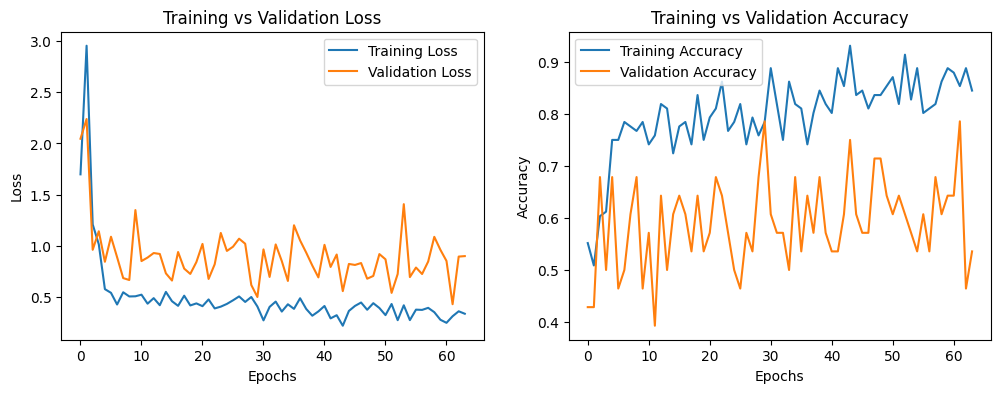

In [6]:
# Plot training & validation loss
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plot training & validation accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step  
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 221ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.50      0.56        14
           1       0.59      0.71      0.65        14

    accuracy                           0.61        28
   macro avg       0.61      0.61      0.60        28
weighted avg       0.61      0.61      0.60        28

Precision: 0.5882
Recall: 0.7143
F1-Score: 0.6452
ROC AUC: 0.6071


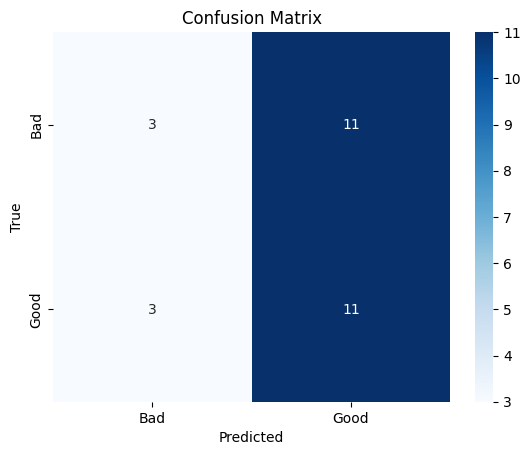

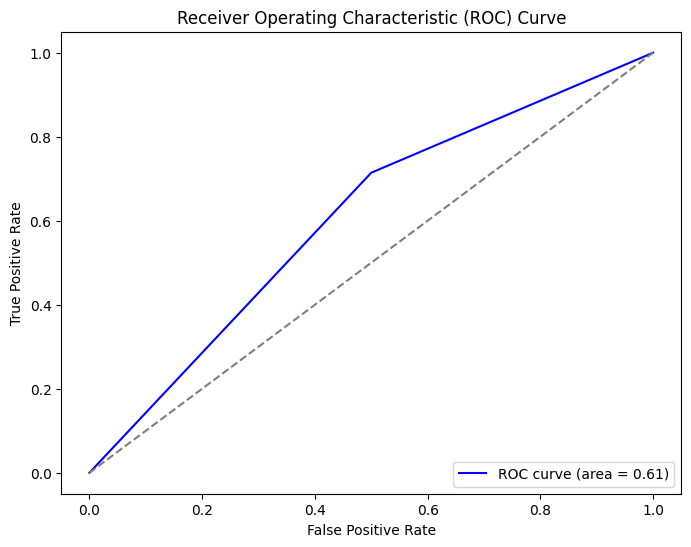

: 

In [7]:
# Get the true labels and predictions from the validation generator
true_labels = validation_generator.classes  # Get the actual labels
predictions = model.predict(validation_generator, verbose=1)  # Get the model's predictions

# Convert probabilities to binary labels (0 or 1) based on a threshold of 0.5
predictions = (predictions >= 0.5).astype(int)

# Compute the confusion matrix
cm = confusion_matrix(true_labels, predictions)

from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import classification_report

# Get the true labels and predictions from the validation generator
true_labels = validation_generator.classes  # Get the actual labels
predictions = model.predict(validation_generator, verbose=1)  # Get the model's predictions

# Convert probabilities to binary labels (0 or 1) based on a threshold of 0.5
predictions = (predictions >= 0.5).astype(int)

# Precision, Recall, F1-Score
precision = precision_score(true_labels, predictions)
recall = recall_score(true_labels, predictions)
f1 = f1_score(true_labels, predictions)

# ROC AUC score (Area Under the Curve for Receiver Operating Characteristic)
roc_auc = roc_auc_score(true_labels, predictions)

# Print the classification report (includes precision, recall, f1-score, and support)
print("Classification Report:")
print(classification_report(true_labels, predictions))

# Print individual metrics
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")

# Optionally, display it more clearly (for binary classification)
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Bad', 'Good'], yticklabels=['Bad', 'Good'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Calculate ROC curve
fpr, tpr, _ = roc_curve(true_labels, predictions)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()